Loading pre-processed train and test data...
Train size: X=(56000, 50), y=(56000,)
Test size: X=(14000, 50), y=(14000,)

Training Baseline Models...

--- Baseline Models Performance ---


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression,0.6100,0.5619,0.2983,0.3897,0.6258
Decision Tree,0.5379,0.4485,0.4661,0.4572,0.5278


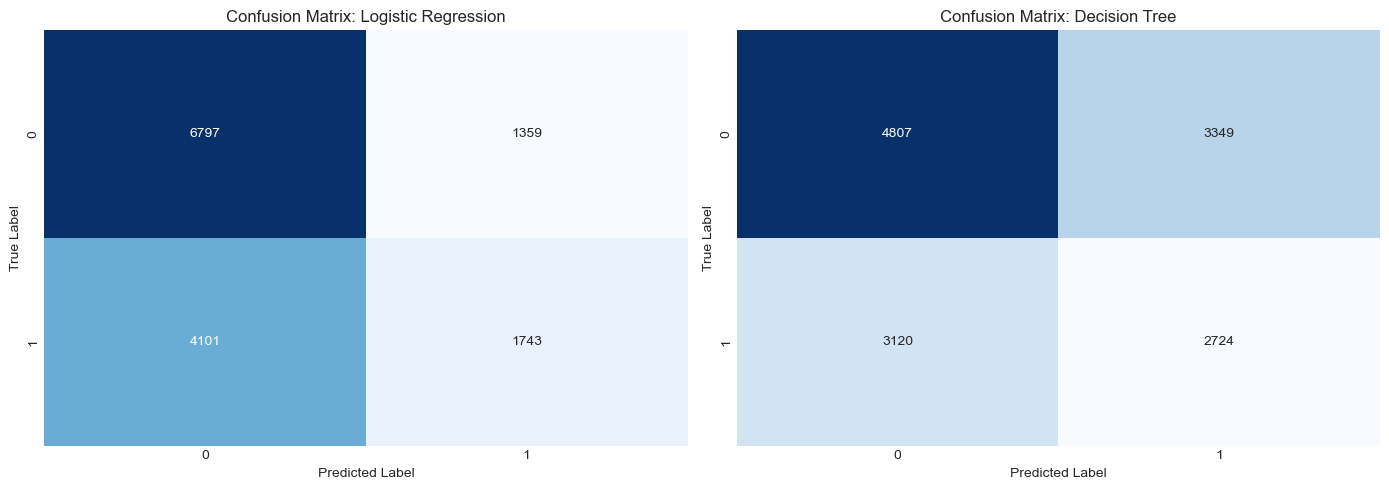

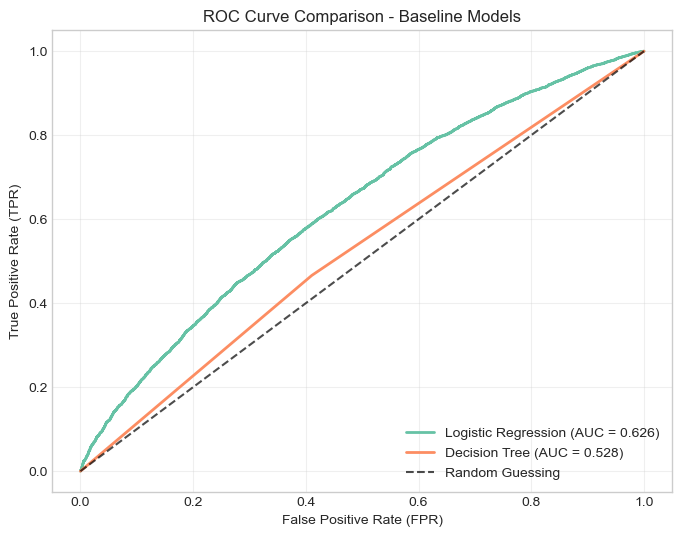


--- Conclusion ---
Logistic Regression performs better overall based on ROC AUC and is less prone to overfitting on the baseline setting.
These baseline metrics will serve as benchmarks for the advanced models (Random Forest, XGBoost) in the next phase.


In [1]:
# ==============================================================================
# NOTEBOOK 09: Baseline Models (Logistic Regression vs Decision Tree)
# Purpose: Train and evaluate baseline models (Logistic Regression & Decision Tree)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

os.makedirs('../data/results', exist_ok=True)
# ═══════════════════════════════════════════════════════════════════════════════
# 1 & 2. Load Pre-split Data (From Notebook 08)
# ═══════════════════════════════════════════════════════════════════════════════
print("Loading pre-processed train and test data...")

# لود کردن فایل‌های جداگانه که در نوت‌بوک ۰۸ اسکیل و انتخاب ویژگی شده‌اند
train_df = pd.read_csv('../data/processed/train_data_final.csv')
test_df = pd.read_csv('../data/processed/test_data_final.csv')

X_train = train_df.drop('Churn', axis=1)
y_train = train_df['Churn']

X_test = test_df.drop('Churn', axis=1)
y_test = test_df['Churn']

print(f"Train size: X={X_train.shape}, y={y_train.shape}")
print(f"Test size: X={X_test.shape}, y={y_test.shape}")

# ═══════════════════════════════════════════════════════════════════════════════
# 3. Model Training (Without Parameter Tuning - Baseline)
# ═══════════════════════════════════════════════════════════════════════════════
print("\nTraining Baseline Models...")

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# ═══════════════════════════════════════════════════════════════════════════════
# 4. Prediction and Evaluation
# ═══════════════════════════════════════════════════════════════════════════════
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_prob)
    }
    
    return metrics, y_pred, y_prob

lr_metrics, lr_pred, lr_prob = evaluate_model(lr_model, X_test, y_test, 'Logistic Regression')
dt_metrics, dt_pred, dt_prob = evaluate_model(dt_model, X_test, y_test, 'Decision Tree')

results_df = pd.DataFrame([lr_metrics, dt_metrics]).set_index('Model')
print("\n--- Baseline Models Performance ---")
display(results_df.round(4))

# ═══════════════════════════════════════════════════════════════════════════════
# 5. Visualization: Confusion Matrix
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (model_name, y_pred) in enumerate([('Logistic Regression', lr_pred), ('Decision Tree', dt_pred)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'Confusion Matrix: {model_name}')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('../data/results/09_confusion_matrices.png', dpi=300)
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 6. Visualization: ROC Curve
# ═══════════════════════════════════════════════════════════════════════════════
plt.figure(figsize=(8, 6))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_metrics["ROC AUC"]:.3f})', linewidth=2)

# Decision Tree ROC
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {dt_metrics["ROC AUC"]:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing', alpha=0.7)

plt.title('ROC Curve Comparison - Baseline Models')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.savefig('../data/results/09_roc_curves.png', dpi=300)
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 7. Comparison and Conclusion
# ═══════════════════════════════════════════════════════════════════════════════
print("\n--- Conclusion ---")
if lr_metrics['ROC AUC'] > dt_metrics['ROC AUC']:
    print("Logistic Regression performs better overall based on ROC AUC and is less prone to overfitting on the baseline setting.")
else:
    print("Decision Tree performs better based on ROC AUC, but keep in mind unpruned trees are highly prone to overfitting.")
print("These baseline metrics will serve as benchmarks for the advanced models (Random Forest, XGBoost) in the next phase.")
